In [1]:
# Import the packages to data handling and visualization

import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
# Load the COVID-19 cleaned dataset into a pandas DataFrame

df = pd.read_csv('c_19_clean_ds.csv')

In [3]:
df.head(2)

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe


In [4]:
# Display concise summary of the DataFrame including column data types and non-null values


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [5]:
# Rename specific columns for clarity and consistency

df.rename(columns={'Province/State': 'state', 'Country/Region': 'country'}, inplace=True)

In [6]:
# Show the number of rows and columns in the DataFrame
df.shape

(49068, 10)

In [7]:
# Count the number of occurrences for each unique date in the dataset


df.Date.value_counts()

Date
2020-01-22    261
2020-05-30    261
2020-05-21    261
2020-05-22    261
2020-05-23    261
             ... 
2020-03-26    261
2020-03-27    261
2020-03-28    261
2020-03-29    261
2020-07-27    261
Name: count, Length: 188, dtype: int64

In [8]:
df.Date.max(), df.Date.min()

('2020-07-27', '2020-01-22')

In [9]:
top_date = df[df.Date == df.Date.max()]

In [10]:
top_date.head(2)

,state,country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
48807,NaN,Afghanistan,33.93911,67.709953,2020-07-27,36263,1269,25198,9796,Eastern Mediterranean
48808,NaN,Albania,41.15330,20.168300,2020-07-27,4880,144,2745,1991,Europe


In [11]:
# Grouping the data with country

top_date.groupby('country')[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum().reset_index()

,country,Confirmed,Deaths,Recovered,Active
0,Afghanistan,36263,1269,25198,9796
1,Albania,4880,144,2745,1991
2,Algeria,27973,1163,18837,7973
3,Andorra,907,52,803,52
4,Angola,950,41,242,667
...,...,...,...,...,...
182,West Bank and Gaza,10621,78,3752,6791
183,Western Sahara,10,1,8,1
184,Yemen,1691,483,833,375
185,Zambia,4552,140,2815,1597


In [12]:
# Confirmed cases on the top date

top_date.groupby('Date')['Confirmed'].sum()

Date
2020-07-27    16480485
Name: Confirmed, dtype: int64

In [13]:
# Function to visualize the data  based on input columns

def plot_for_columns(column_name):
    case = df.groupby('Date')[column_name].sum().reset_index()

    plt.figure(figsize=(12, 4))
    sns.lineplot(data = case, x= 'Date', y=column_name)
    plt.title(f'Graph for covid {column_name} cases')
    plt.xlabel('Date')
    plt.ylabel(column_name)
    plt.show()


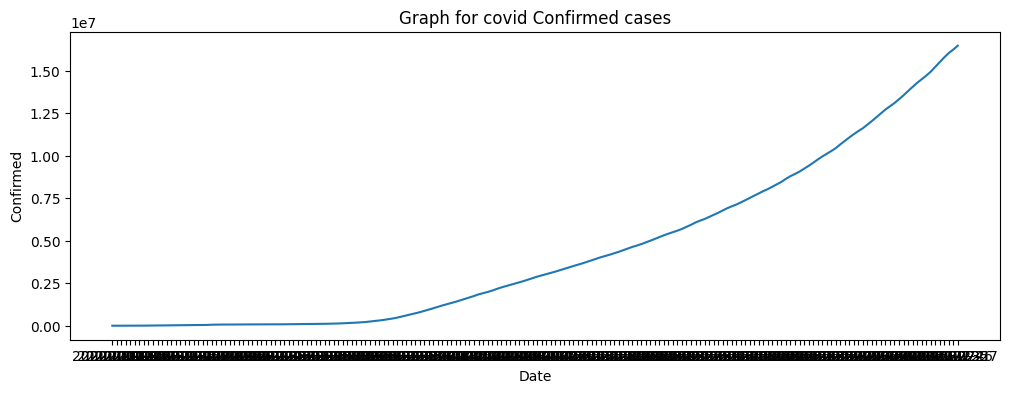

In [14]:
#   Visualizing the confirmed columns

plot_for_columns('Confirmed')

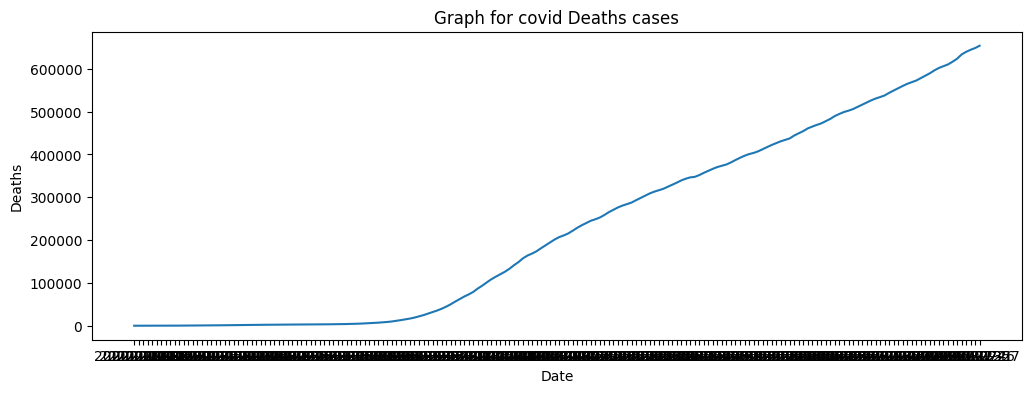

In [15]:
# Graphing the Death rate over the period of time

plot_for_columns('Deaths')

In [16]:
# grouping the dataset by Date and confirm to forecast
confirm_df = df.groupby('Date')['Confirmed'].sum().reset_index()

In [17]:
# Prophet consider `ds` as data column and `y` as value

confirm_df.columns = ['ds', 'y']

confirm_df

,ds,y
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [18]:
# Splitting the dataset into train and test

confirm_train, confirm_test = confirm_df[:-5], confirm_df[-5: ]

In [19]:
# Importing the prophet module

from prophet import Prophet

In [20]:
# Initalizing and training the model

prop = Prophet()
prop.fit(confirm_train)

12:55:43 - cmdstanpy - INFO - Chain [1] start processing
12:55:43 - cmdstanpy - INFO - Chain [1] done processing


In [21]:
# Initialize the forecasting periods and predicting the values

forecast_period = prop.make_future_dataframe(periods = 5)
forecasted = prop.predict(forecast_period)

In [22]:
# Seperate the predicted value  to calculate error

prediction = forecasted['yhat']

In [23]:
# Importing the metrics module
from sklearn.metrics import *
import numpy as np


#Root mean squared error to evaluate the model prediction 
np.sqrt(mean_squared_error(prediction[-5:], confirm_test['y']))

581471.5803989767

In [24]:
# Training the model with whole Death case and forecasting for next 2 weeks

death_df = df.groupby('Date')['Deaths'].sum().reset_index()

death_df.columns = ['ds', 'y']

In [25]:
# Custom function to forecast the n input periods
def forecast(df, period):
    prop = Prophet()
    prop.fit(df)
    forecast_period = prop.make_future_dataframe(periods = period)
    forecasted = prop.predict(forecast_period)
    forecasted = forecasted[len(df): ]
    return forecasted
    

In [26]:
# Forecasting the deathrate
forecasted_data = forecast(death_df, 15)

12:55:44 - cmdstanpy - INFO - Chain [1] start processing
12:55:44 - cmdstanpy - INFO - Chain [1] done processing


In [27]:
# Spliting the data and forecasted columns 
forecasted_data = forecasted_data[['ds', 'yhat']]

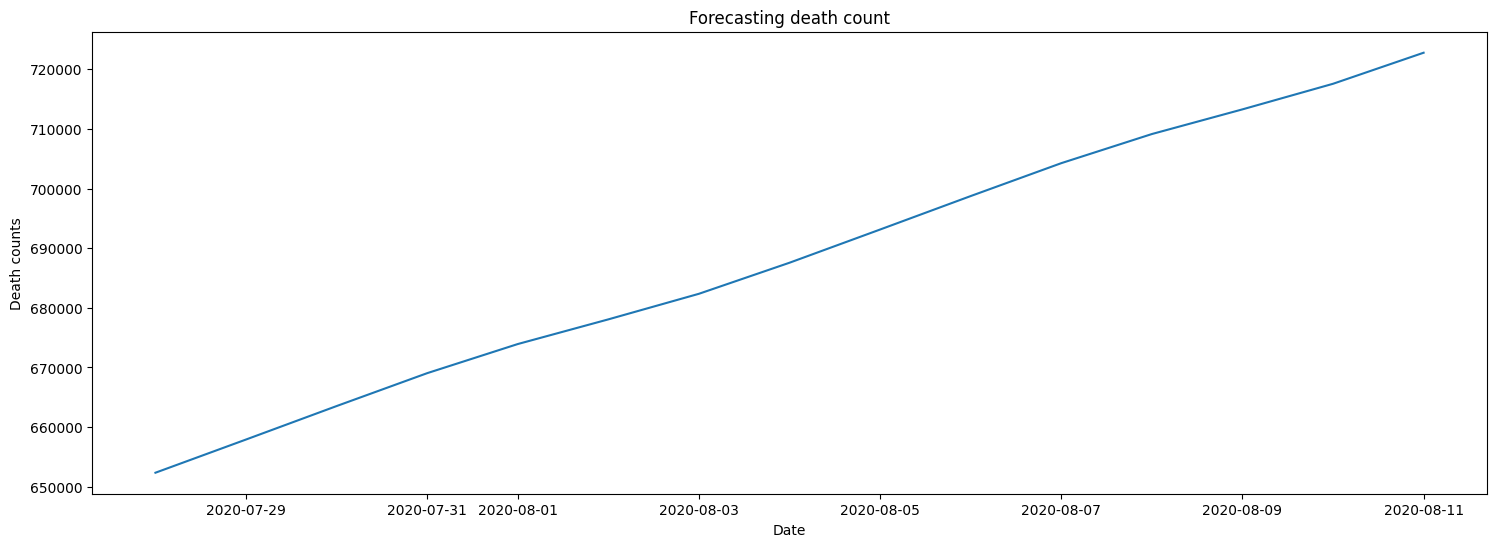

In [28]:
# visulaizing the forecasted death rate. 

plt.figure(figsize=(18, 6))
sns.lineplot(data=forecasted_data, x = 'ds', y = 'yhat')
plt.title('Forecasting death count')
plt.xlabel('Date')
plt.ylabel('Death counts')
plt.show()

